# **Stage 02 v2 — Intraday Data Analysis**

```
S02_intraday_data_analysis_v2.ipynb
```


## Alcance

Esta notebook **no contiene logica de negocio**. Toda la logica vive en
`src/data/s02_intraday_analysis.py`. Esta notebook solo la invoca y muestra
resultados.

- No modifica `notebooks/S02_intraday_data_analysis.ipynb` (v1, evidencia historica intacta).
- No modifica nada de S00 ni S01 (config, modulos, artefactos de `data/01_raw/` y `data/02_intraday/mnq_intraday_v2.parquet`).
- Parte exclusivamente de los artefactos aprobados de S01 v2 (`mnq_intraday_v2.parquet`, `trading_day_audit_v2.parquet`).
- No construye, evalua ni selecciona targets (DIR/BAR/OPC): eso es responsabilidad de S04 en adelante.
- No ejecuta el generador exploratorio de features de la notebook historica (queda como antecedente legacy, fuera de este pipeline).
- "Cambio estructural" nunca se usa como conclusion aqui: el diagnostico de inestabilidad temporal es exploratorio (rolling + zonas percentilicas), no una prueba formal de ruptura.
- Toda ventana historica o futura exige simultaneamente: mismo `date`, mismo tramo de minutos consecutivos, mismo `contract` y consecutividad estricta de minuto a minuto. Un cambio de contrato dentro de la ventana es bloqueante, no solo diagnostico.

Poblaciones (ver `01_CURRENT_DECISIONS.md` y la revision tecnica de S02 v2):

| Poblacion | Uso |
|---|---|
| `all` | cobertura, calidad, descriptivo |
| `full_day_eligible` | poblacion cuantitativa principal |
| `partial_regime_eligible` | secundaria, solo regimenes marcados consecutivos por S01 |
| `descriptive_only` | solo descripcion |
| `not_model_eligible` (implicito) | excluida de ventanas y metricas para stages posteriores |


## 0. Configuracion del entorno

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path, marker: str = "config/s02_analysis_config.yaml", max_levels: int = 15) -> Path:
    current = start.resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"No se encontro un ancestro de {start} que contenga {marker} en {max_levels} niveles"
    )


PROJECT_ROOT = find_project_root(Path.cwd())
print("Project root:", PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


Project root: C:\Users\heguu\OneDrive\Escritorio\neural_profit


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.data import s02_intraday_analysis as s02

CONFIG_PATH = PROJECT_ROOT / "config" / "s02_analysis_config.yaml"
print("Config:", CONFIG_PATH)


Config: C:\Users\heguu\OneDrive\Escritorio\neural_profit\config\s02_analysis_config.yaml


## 1. Ejecucion productiva

Una sola llamada de orquestacion; toda la logica (poblaciones, validacion, metricas OHLCV, ventanas, resumenes, dependencia temporal, gobernanza) vive en el modulo.

In [3]:
result = s02.run_s02_analysis(project_root=PROJECT_ROOT, config_path=CONFIG_PATH)

print("Directorio de salida:", result.output_dir)
print("Manifest:", result.manifest_path)
print("Pipeline version:", result.manifest["pipeline_version"])
print("Artefactos escritos:")
for name, info in result.manifest["output_files"].items():
    print(f"  {name}: {info['rows']} filas -> {info['path']}")


Directorio de salida: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday
Manifest: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_analysis_manifest.json
Pipeline version: s02_v2
Artefactos escritos:
  s02_summary: 4 filas -> C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_summary.parquet
  s02_coverage_summary: 146 filas -> C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_coverage_summary.parquet
  s02_regime_distribution: 307 filas -> C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_regime_distribution.parquet
  s02_ohlcv_stats_summary: 3724 filas -> C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_ohlcv_stats_summary.parquet
  s02_ohlcv_correlation: 182 filas -> C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_ohlcv_correlation.parquet
  s02_window_validity_summary: 18 filas -> C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday

## 2. Validacion temporal (gap-aware, por segmento)

Adaptacion de la validacion historica: escapada por `consecutive_segment_id`, no aborta por gaps intradiarios reales entre segmentos (legitimos en jornadas parciales de v2), pero sigue siendo critica ante duplicados, desorden global o pasos no consecutivos dentro de un mismo segmento.

In [4]:
print("Validacion OK:", result.validation["ok"])
print(pd.Series(result.validation["checks"]))
print()
print(pd.Series(result.validation["summary"]))


Validacion OK: True
index_is_monotonic_increasing                True
index_is_unique                              True
date_column_matches_index_date               True
all_global_time_diffs_positive               True
segments_are_strictly_consecutive_minutes    True
no_duplicate_minute_of_day_within_day        True
dtype: bool

n_non_positive_global_diffs                                          0
n_bad_steps_within_segment                                           0
n_duplicate_minute_of_day_within_day                                 0
n_intraday_gaps_within_date_informational                          498
n_rows                                                         1087777
n_dates                                                           1787
n_segments                                                        2285
start                                        2019-12-23 04:30:00-05:00
end                                          2026-04-17 16:00:00-04:00
dtype: object


## 3. Poblacion y elegibilidad

`s02_summary.parquet` -- resumen liviano por poblacion (grano: 1 fila por poblacion).

In [5]:
result.tables["s02_summary"]

,population,n_rows,n_dates,first_timestamp,last_timestamp,avg_bars_per_day,pct_of_total_rows
0,all,1087777,1787,2019-12-23 04:30:00-05:00,2026-04-17 16:00:00-04:00,608.716844,100.000000
1,full_day_eligible,1024062,1482,2020-01-02 04:30:00-05:00,2026-04-17 16:00:00-04:00,691.000000,94.142641
2,partial_regime_eligible,40539,119,2019-12-23 08:30:00-05:00,2026-04-03 08:29:00-04:00,340.663866,3.726775
3,descriptive_only,1359,182,2019-12-28 14:46:00-05:00,2026-04-05 09:50:00-04:00,7.467033,0.124934


## 4. Cobertura temporal (todos los datos observados)

`s02_coverage_summary.parquet` -- cobertura por year/quarter/month/contract/day_status/eligibility_category, calculada sobre la poblacion `all` (decision de reconstruccion: cobertura y calidad usan todos los datos observados, no solo `full_day_eligible`).

In [6]:
cov = result.tables["s02_coverage_summary"]
display(cov.loc[cov["cut_dimension"] == "year"])
display(cov.loc[cov["cut_dimension"] == "eligibility_category"])
display(cov.loc[cov["cut_dimension"] == "day_status"])


,cut_dimension,cut_value,n_rows,n_dates,avg_bars_per_day_observed,pct_of_total_rows
0,year,2019,3948,7,564.000000,0.362942
1,year,2020,173925,292,595.633562,15.989031
2,year,2021,175686,285,616.442105,16.150921
3,year,2022,175262,288,608.548611,16.111942
4,year,2023,170179,267,637.374532,15.644659
5,year,2024,174970,286,611.783217,16.085098
6,year,2025,163821,283,578.872792,15.060164
7,year,2026,49986,79,632.734177,4.595243


,cut_dimension,cut_value,n_rows,n_dates,avg_bars_per_day_observed,pct_of_total_rows
142,eligibility_category,descriptive_only,1359,182,7.467033,0.124934
143,eligibility_category,full_day_eligible,1024062,1482,691.000000,94.142641
144,eligibility_category,not_model_eligible,877,4,219.250000,0.080623
145,eligibility_category,partial_regime_eligible,61479,119,516.630252,5.651802


,cut_dimension,cut_value,n_rows,n_dates,avg_bars_per_day_observed,pct_of_total_rows
138,day_status,full_coverage,1024062,1482,691.000000,94.142641
139,day_status,partial_early_close_cme,28626,57,502.210526,2.631606
140,day_status,partial_gap_documented_s00,877,4,219.250000,0.080623
141,day_status,partial_undetermined,34212,244,140.213115,3.145130


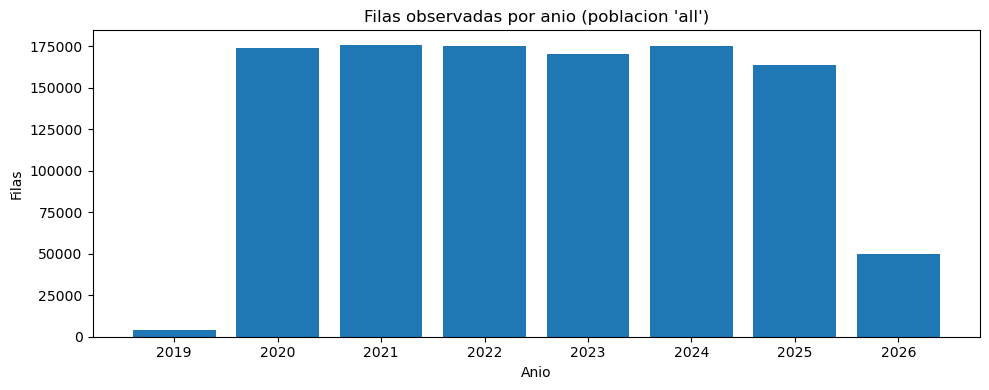

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
by_year = cov.loc[cov["cut_dimension"] == "year"].sort_values("cut_value")
ax.bar(by_year["cut_value"].astype(str), by_year["n_rows"])
ax.set_title("Filas observadas por anio (poblacion 'all')")
ax.set_xlabel("Anio")
ax.set_ylabel("Filas")
plt.tight_layout()
plt.show()


## 5. Regimen intradiario

`s02_regime_distribution.parquet` -- distribucion por poblacion x corte (overall/year/contract), usando `regime_label` de S01 v2 (ya corregido: `Regular` 10:30-14:59, `Closing` 15:00-16:00, sin ruta default). `partial_regime_eligible` solo incluye barras cuyo regimen esta marcado consecutivo por S01.

In [8]:
regime_dist = result.tables["s02_regime_distribution"]
display(regime_dist.loc[(regime_dist["population"] == "full_day_eligible") & (regime_dist["cut_dimension"] == "overall")])
display(regime_dist.loc[(regime_dist["population"] == "partial_regime_eligible") & (regime_dist["cut_dimension"] == "overall")])


,population,cut_dimension,cut_value,regime_id,regime_label,n_bars,n_days,pct_within_cut
0,full_day_eligible,overall,overall,0,Early_Premarket,355680,1482,34.732272
1,full_day_eligible,overall,overall,1,Premarket,88920,1482,8.683068
2,full_day_eligible,overall,overall,2,Opening,88920,1482,8.683068
3,full_day_eligible,overall,overall,3,Regular,400140,1482,39.073806
4,full_day_eligible,overall,overall,4,Closing,90402,1482,8.827786


,population,cut_dimension,cut_value,regime_id,regime_label,n_bars,n_days,pct_within_cut
170,partial_regime_eligible,overall,overall,0,Early_Premarket,18240,76,44.993710
171,partial_regime_eligible,overall,overall,1,Premarket,6420,107,15.836602
172,partial_regime_eligible,overall,overall,2,Opening,5400,90,13.320506
173,partial_regime_eligible,overall,overall,3,Regular,8100,30,19.980759
174,partial_regime_eligible,overall,overall,4,Closing,2379,39,5.868423


## 6. Metricas OHLCV descriptivas

Causales, calculadas dentro de cada `consecutive_segment_id` (no de cada `date`, para no cruzar gaps internos de jornadas parciales). `body_signed_pts` (con signo) y `body_abs_pts` (valor absoluto) reemplazan al ambiguo `body_pts` historico.

In [9]:
df_full = result.df_ohlcv_by_population["full_day_eligible"]
preview_cols = [
    "date", "minute_of_day", "regime_label", "contract", "close",
    "ret_1m", "log_ret_1m", "range_pts", "body_signed_pts", "body_abs_pts",
    "close_position", "log_volume",
]
df_full[preview_cols].head(10)


,date,minute_of_day,regime_label,contract,close,ret_1m,log_ret_1m,range_pts,body_signed_pts,body_abs_pts,close_position,log_volume
datetime,,,,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,Early_Premarket,H20,8813.25,NaN,NaN,0.75,0.00,0.00,1.000000,2.639057
2020-01-02 04:31:00-05:00,2020-01-02,271,Early_Premarket,H20,8812.50,-0.000085,-0.000085,1.50,0.00,0.00,1.000000,4.804021
2020-01-02 04:32:00-05:00,2020-01-02,272,Early_Premarket,H20,8811.75,-0.000085,-0.000085,1.50,-0.75,0.75,0.000000,3.988984
2020-01-02 04:33:00-05:00,2020-01-02,273,Early_Premarket,H20,8810.50,-0.000142,-0.000142,1.75,-1.50,1.50,0.000000,3.637586
2020-01-02 04:34:00-05:00,2020-01-02,274,Early_Premarket,H20,8812.00,0.000170,0.000170,1.75,1.25,1.25,0.857143,3.610918
2020-01-02 04:35:00-05:00,2020-01-02,275,Early_Premarket,H20,8813.00,0.000113,0.000113,1.00,1.00,1.00,1.000000,3.555348
2020-01-02 04:36:00-05:00,2020-01-02,276,Early_Premarket,H20,8813.25,0.000028,0.000028,1.00,0.00,0.00,0.500000,4.234107
2020-01-02 04:37:00-05:00,2020-01-02,277,Early_Premarket,H20,8813.25,0.000000,0.000000,0.50,-0.25,0.25,0.000000,3.637586
2020-01-02 04:38:00-05:00,2020-01-02,278,Early_Premarket,H20,8814.00,0.000085,0.000085,1.00,0.50,0.50,0.500000,3.912023


## 7. Estadistica general OHLCV

`s02_ohlcv_stats_summary.parquet` (percentiles por poblacion x corte x metrica) y `s02_ohlcv_correlation.parquet` (Pearson/Spearman sobre `full_day_eligible`).

In [10]:
stats = result.tables["s02_ohlcv_stats_summary"]
display(stats.loc[(stats["population"] == "full_day_eligible") & (stats["cut_dimension"] == "overall")])


,count,mean,std,min,max,n_inf,n_nan,p01,p05,p25,p50,p75,p95,p99,population,cut_dimension,cut_value,metric
938,1022580,7.382063e-03,7.335358,-357.750000,438.500000,0,1482,-21.250000,-10.500000,-2.750000,0.000000,3.000000,10.250000,20.500000,full_day_eligible,overall,overall,delta_close_1m
939,1022580,7.441607e-07,0.000490,-0.030505,0.025963,0,1482,-0.001425,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001382,full_day_eligible,overall,overall,ret_1m
940,1022580,6.239006e-07,0.000490,-0.030980,0.025631,0,1482,-0.001426,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001381,full_day_eligible,overall,overall,log_ret_1m
941,1022580,4.562124e+00,5.744086,0.000000,438.500000,0,1482,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,full_day_eligible,overall,overall,abs_delta_close_1m
942,1022580,3.005456e-04,0.000388,0.000000,0.030505,0,1482,0.000000,0.000017,0.000080,0.000184,0.000380,0.000968,0.001784,full_day_eligible,overall,overall,abs_ret_1m
943,1024062,9.223619e+00,8.097460,0.000000,592.250000,0,0,1.250000,2.250000,4.250000,7.000000,11.500000,23.500000,38.750000,full_day_eligible,overall,overall,range_pts
944,1024062,6.062953e-04,0.000548,0.000000,0.034062,0,0,0.000084,0.000136,0.000273,0.000453,0.000757,0.001575,0.002650,full_day_eligible,overall,overall,range_pct
945,1024062,3.490755e-03,7.311978,-318.750000,443.500000,0,0,-21.000000,-10.500000,-2.750000,0.000000,3.000000,10.250000,20.500000,full_day_eligible,overall,overall,body_signed_pts
946,1024062,4.543876e+00,5.728717,0.000000,443.500000,0,0,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,full_day_eligible,overall,overall,body_abs_pts
947,1024062,2.298358e+00,2.850428,0.000000,139.250000,0,0,0.000000,0.000000,0.500000,1.500000,3.000000,7.250000,13.250000,full_day_eligible,overall,overall,upper_wick_pts


In [11]:
corr = result.tables["s02_ohlcv_correlation"]
corr.loc[corr["method"] == "pearson"].reindex(corr["correlation"].abs().sort_values(ascending=False).index).head(15)


,population,metric_a,metric_b,method,correlation
104,NaN,NaN,NaN,NaN,NaN
13,full_day_eligible,ret_1m,log_ret_1m,pearson,0.999997
6,full_day_eligible,delta_close_1m,body_signed_pts,pearson,0.997906
40,full_day_eligible,abs_delta_close_1m,body_abs_pts,pearson,0.996823
97,NaN,NaN,NaN,NaN,NaN
92,NaN,NaN,NaN,NaN,NaN
91,NaN,NaN,NaN,NaN,NaN
109,NaN,NaN,NaN,NaN,NaN
120,NaN,NaN,NaN,NaN,NaN
131,NaN,NaN,NaN,NaN,NaN


## 8. Ventanas operativas 30/60/90 minutos

Convencion sin cambios: historica `[t-h+1, t]` (h barras, h-1 intervalos), futura `[t+1, t+h]` (h barras, h intervalos) -- asimetria intencional, documentada explicitamente aqui para evitar comparaciones erroneas entre ambas (ver problema S02-02).

Una ventana es valida solo si, simultaneamente: mismo `date`, mismo tramo de minutos consecutivos, mismo `contract` y consecutividad estricta. El bloqueo por cambio de contrato es nuevo respecto de la notebook historica.

In [12]:
wv = result.tables["s02_window_validity_summary"]
wv


,population,horizon_minutes,window_type,total_rows,valid_rows,invalid_rows,invalid_insufficient_bars,invalid_contract_change,pct_valid
0,full_day_eligible,30,historical,1024062,981084,42978,42978.0,0.0,95.803184
1,full_day_eligible,30,future,1024062,979602,44460,44460.0,0.0,95.658466
2,full_day_eligible,30,full,1024062,936624,87438,NaN,NaN,91.461650
3,full_day_eligible,60,historical,1024062,936624,87438,87438.0,0.0,91.461650
4,full_day_eligible,60,future,1024062,935142,88920,88920.0,0.0,91.316932
5,full_day_eligible,60,full,1024062,847704,176358,NaN,NaN,82.778582
6,full_day_eligible,90,historical,1024062,892164,131898,131898.0,0.0,87.120116
7,full_day_eligible,90,future,1024062,890682,133380,133380.0,0.0,86.975398
8,full_day_eligible,90,full,1024062,758784,265278,NaN,NaN,74.095514
9,partial_regime_eligible,30,historical,40539,36624,3915,3915.0,0.0,90.342633


## 9. Auditoria de ventanas afectadas por rollover

`s02_rollover_window_audit.parquet` -- cuantifica el impacto especifico a nivel de ventana de cada transicion de contrato (no duplica la auditoria general de rollover prevista como Fase 4 del rebuild plan, que audita las transiciones crudas).

In [13]:
rollover = result.tables["s02_rollover_window_audit"]
print(f"Transiciones de contrato detectadas: {rollover['contract_before'].groupby(rollover['transition_id']).count().shape[0] if len(rollover) else 0}")
print(f"Transiciones intra-segmento (con impacto potencial de ventana): {int(rollover['intra_segment_transition'].sum() / max(len(rollover.groupby('transition_id')), 1)) if len(rollover) else 0}")
rollover.loc[rollover["intra_segment_transition"]]


Transiciones de contrato detectadas: 25
Transiciones intra-segmento (con impacto potencial de ventana): 0


,population,transition_id,contract_before,contract_after,last_bar_before_ts,first_bar_after_ts,gap_minutes_between_contracts,intra_segment_transition,horizon_minutes,n_bars_hist_invalidated_by_contract,n_bars_future_invalidated_by_contract


## 10. Metricas por ventana agregadas (por anio/trimestre/contrato/regimen)

`s02_window_metrics_summary.parquet` -- estadisticos agregados (no per-barra) de las metricas historicas/futuras, por poblacion x horizonte x corte. Reemplaza al parquet masivo por-barra de la notebook historica (`df_window_metrics`, 1.024.062 x 156), que no debe versionarse.

In [14]:
wms = result.tables["s02_window_metrics_summary"]
excursion = wms.loc[
    (wms["population"] == "full_day_eligible")
    & (wms["metric_base"] == "max_excursion_pts")
    & (wms["cut_dimension"] == "overall")
]
excursion[["horizon_minutes", "window_type", "count", "p50", "p95", "max"]]


,horizon_minutes,window_type,count,p50,p95,max
845,30,future,979602,30.75,106.25,1463.25
1755,60,future,935142,45.00,151.50,1654.00
2658,90,future,890682,57.00,186.50,1654.00


## 11. Estabilidad temporal (coeficiente de variacion)

`s02_stability_summary.parquet` -- dispersion de `p50`/`p95` entre grupos de cada corte (year/quarter/contract/regime), a partir del resumen agregado por ventana.

In [15]:
stability = result.tables["s02_stability_summary"]
stability.loc[stability["metric_base"] == "max_excursion_pts"].sort_values("p50_cv", ascending=False).head(15)


,population,context_name,horizon_minutes,window_type,metric_base,n_groups,p50_min,p50_max,p50_cv,p50_stability,top_p50_group,low_p50_group,p95_cv,p95_stability
293,partial_regime_eligible,quarter,90,future,max_excursion_pts,27,10.750,141.25,0.715821,inestable,2020Q1,2021Q1,0.775364,inestable
237,partial_regime_eligible,quarter,60,future,max_excursion_pts,27,9.250,112.75,0.694892,inestable,2020Q1,2021Q1,0.665327,inestable
181,partial_regime_eligible,quarter,30,future,max_excursion_pts,27,7.125,79.75,0.676627,inestable,2020Q1,2021Q1,0.644460,inestable
292,partial_regime_eligible,contract,90,future,max_excursion_pts,26,10.000,59.75,0.476808,inestable,H22,H21,0.747720,inestable
236,partial_regime_eligible,contract,60,future,max_excursion_pts,26,8.750,48.00,0.469869,inestable,M22,H21,0.644251,inestable
183,partial_regime_eligible,year,30,future,max_excursion_pts,8,8.000,32.75,0.445460,inestable,2026,2019,0.535564,inestable
180,partial_regime_eligible,contract,30,future,max_excursion_pts,26,6.750,36.75,0.443782,inestable,U24,H21,0.607953,inestable
239,partial_regime_eligible,year,60,future,max_excursion_pts,8,12.000,44.25,0.433923,inestable,2026,2019,0.544167,inestable
295,partial_regime_eligible,year,90,future,max_excursion_pts,8,15.500,50.25,0.423188,inestable,2026,2019,0.520065,inestable
126,full_day_eligible,regime,90,future,max_excursion_pts,4,38.750,98.50,0.380556,inestable,Premarket,Early_Premarket,0.261358,moderada


## 12. Rolling

`s02_rolling_summary.parquet` -- medianas rolling de 20/60/120 dias sobre `future_max_excursion_pts` diario.

In [16]:
rolling = result.tables["s02_rolling_summary"]
rolling.loc[(rolling["population"] == "full_day_eligible") & (rolling["stat"] == "p50")]


,population,rolling_window_days,horizon_minutes,metric_base,stat,first_valid_date,last_valid_date,latest_value,min_value,max_value,mean_value,median_value
0,full_day_eligible,20,30,future_max_excursion_pts,p50,2020-01-22 00:00:00,2026-04-17 00:00:00,52.750,10.125,75.625,32.163887,29.500
2,full_day_eligible,20,60,future_max_excursion_pts,p50,2020-01-22 00:00:00,2026-04-17 00:00:00,75.500,14.625,108.625,47.145252,43.625
4,full_day_eligible,20,90,future_max_excursion_pts,p50,2020-01-22 00:00:00,2026-04-17 00:00:00,100.625,18.750,139.500,60.288887,56.000
6,full_day_eligible,60,30,future_max_excursion_pts,p50,2020-03-03 00:00:00,2026-04-17 00:00:00,56.000,13.875,56.250,31.232564,28.625
8,full_day_eligible,60,60,future_max_excursion_pts,p50,2020-03-03 00:00:00,2026-04-17 00:00:00,76.750,20.750,79.125,45.920455,42.500
10,full_day_eligible,60,90,future_max_excursion_pts,p50,2020-03-03 00:00:00,2026-04-17 00:00:00,97.750,26.750,104.625,58.840996,53.875
12,full_day_eligible,120,30,future_max_excursion_pts,p50,2020-05-14 00:00:00,2026-04-17 00:00:00,46.875,19.750,47.875,30.570675,28.125
14,full_day_eligible,120,60,future_max_excursion_pts,p50,2020-05-14 00:00:00,2026-04-17 00:00:00,71.625,29.500,71.875,45.333452,41.375
16,full_day_eligible,120,90,future_max_excursion_pts,p50,2020-05-14 00:00:00,2026-04-17 00:00:00,91.125,36.875,91.625,57.936294,53.125


## 13. Diagnostico de inestabilidad temporal (ex "cambios estructurales")

`s02_temporal_instability_zones.parquet` -- marca periodos altos/extremos por percentil rolling. Es un **diagnostico exploratorio**, no una prueba formal de ruptura (Chow/CUSUM/Bai-Perron quedan fuera de alcance de esta etapa, por decision del usuario).

In [17]:
zones = result.tables["s02_temporal_instability_zones"]
extreme = zones.loc[(zones["population"] == "full_day_eligible") & (zones["zone"] == "extremo")]
extreme.sort_values(["rolling_window_days", "horizon_minutes", "days"], ascending=[True, True, False]).head(20)


,population,year,year_quarter,zone,days,value_median,value_max,rolling_window_days,horizon_minutes,p_high_threshold,p_extreme_threshold
17,full_day_eligible,2022,2022Q1,extremo,34,52.1250,55.875,20,30,37.625,47.75
46,full_day_eligible,2026,2026Q1,extremo,32,57.5000,61.375,20,30,37.625,47.75
39,full_day_eligible,2025,2025Q2,extremo,27,61.0000,75.625,20,30,37.625,47.75
20,full_day_eligible,2022,2022Q2,extremo,20,52.7500,56.000,20,30,37.625,47.75
48,full_day_eligible,2026,2026Q2,extremo,12,57.9375,61.375,20,30,37.625,47.75
43,full_day_eligible,2025,2025Q4,extremo,9,53.1250,55.750,20,30,37.625,47.75
36,full_day_eligible,2025,2025Q1,extremo,8,69.6250,69.625,20,30,37.625,47.75
1,full_day_eligible,2020,2020Q1,extremo,5,50.8750,50.875,20,30,37.625,47.75
4,full_day_eligible,2020,2020Q2,extremo,4,50.8750,50.875,20,30,37.625,47.75
96,full_day_eligible,2026,2026Q1,extremo,32,76.3750,90.875,20,60,55.500,71.00


## 14. Dependencia temporal: ACF, Ljung-Box, ARCH-LM

Diagnostico acotado sobre `ret_1m`, `abs_ret_1m` y `squared_ret_1m` (poblacion `full_day_eligible`), global y por regimen cuando la muestra es suficiente (`min_obs_regime` en la config). **No se usa todavia para seleccionar features** -- esa decision pertenece a S05.

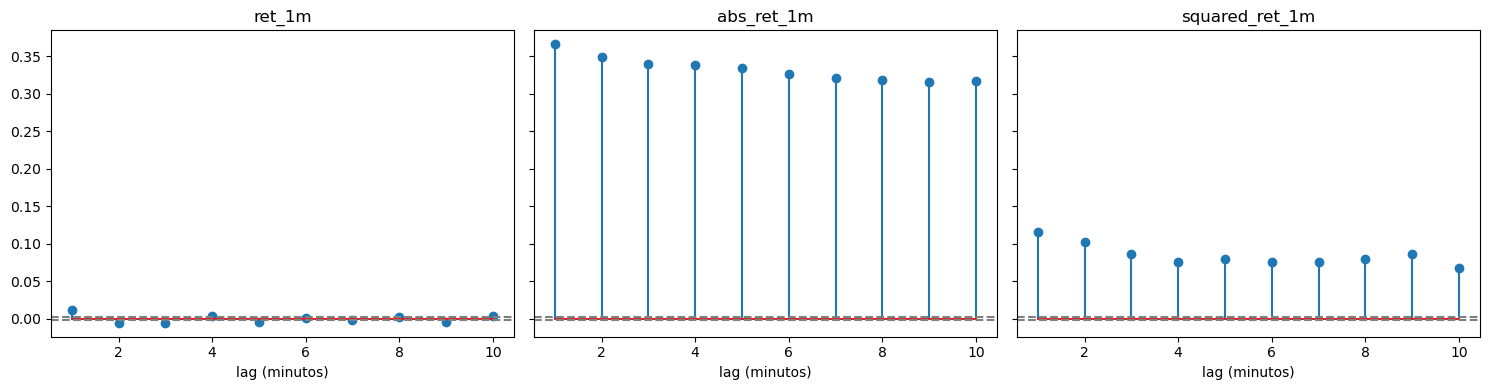

In [18]:
acf_table = result.tables["s02_acf_summary"]
global_acf = acf_table.loc[acf_table["scope"] == "global"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, series_name in zip(axes, ["ret_1m", "abs_ret_1m", "squared_ret_1m"]):
    sub = global_acf.loc[global_acf["series"] == series_name]
    ax.stem(sub["lag"], sub["acf_value"])
    ax.axhline(sub["conf_bound_95"].iloc[0], color="gray", linestyle="--")
    ax.axhline(-sub["conf_bound_95"].iloc[0], color="gray", linestyle="--")
    ax.set_title(series_name)
    ax.set_xlabel("lag (minutos)")
plt.tight_layout()
plt.show()


In [19]:
dep_tests = result.tables["s02_dependence_tests_summary"]
dep_tests.loc[dep_tests["scope"] == "global"]


,population,scope,regime_id,regime_label,series,test_name,statistic,p_value,lags_used,n_obs,sufficient_sample,n_pairs_effective_at_max_lag
0,full_day_eligible,global,NaN,NaN,ret_1m,ljung_box,2.479769e+02,0.000000e+00,10,1022580,True,1007760.0
1,full_day_eligible,global,NaN,NaN,ret_1m,arch_lm,4.230566e+04,0.000000e+00,10,1022580,True,NaN
2,full_day_eligible,global,NaN,NaN,abs_ret_1m,ljung_box,1.140166e+06,0.000000e+00,10,1022580,True,1007760.0
3,full_day_eligible,global,NaN,NaN,abs_ret_1m,arch_lm,4.230566e+04,0.000000e+00,10,1022580,True,NaN
4,full_day_eligible,global,NaN,NaN,squared_ret_1m,ljung_box,7.517202e+04,0.000000e+00,10,1022580,True,1007760.0
5,full_day_eligible,global,NaN,NaN,squared_ret_1m,arch_lm,2.731966e+02,7.087545e-53,10,1022580,True,NaN


In [20]:
dep_tests.loc[(dep_tests["scope"] == "regime") & dep_tests["sufficient_sample"]].sort_values(["series", "test_name", "regime_id"])


,population,scope,regime_id,regime_label,series,test_name,statistic,p_value,lags_used,n_obs,sufficient_sample,n_pairs_effective_at_max_lag
9,full_day_eligible,regime,0.0,Early_Premarket,abs_ret_1m,arch_lm,48703.748895,0.000000e+00,10,354198,True,NaN
15,full_day_eligible,regime,1.0,Premarket,abs_ret_1m,arch_lm,407.548385,2.327795e-81,10,88920,True,NaN
21,full_day_eligible,regime,2.0,Opening,abs_ret_1m,arch_lm,12357.596588,0.000000e+00,10,88920,True,NaN
27,full_day_eligible,regime,3.0,Regular,abs_ret_1m,arch_lm,44146.354454,0.000000e+00,10,400140,True,NaN
33,full_day_eligible,regime,4.0,Closing,abs_ret_1m,arch_lm,10727.304451,0.000000e+00,10,90402,True,NaN
8,full_day_eligible,regime,0.0,Early_Premarket,abs_ret_1m,ljung_box,330340.924128,0.000000e+00,10,354198,True,339378.0
14,full_day_eligible,regime,1.0,Premarket,abs_ret_1m,ljung_box,36029.020190,0.000000e+00,10,88920,True,74100.0
20,full_day_eligible,regime,2.0,Opening,abs_ret_1m,ljung_box,50844.258892,0.000000e+00,10,88920,True,74100.0
26,full_day_eligible,regime,3.0,Regular,abs_ret_1m,ljung_box,358330.519169,0.000000e+00,10,400140,True,385320.0
32,full_day_eligible,regime,4.0,Closing,abs_ret_1m,ljung_box,80112.036464,0.000000e+00,10,90402,True,75582.0


## 15. Implicancias para etapas posteriores

Estos hallazgos son antecedentes para etapas posteriores, no decisiones tomadas por S02:

- Los horizontes candidatos (30/60/90 minutos) y la prioridad exploratoria de `h60` se reevaluan aqui con el dataset v2 y la definicion de regimen vigente; la seleccion final de horizonte es responsabilidad de S03/S04.
- La construccion, evaluacion y seleccion de targets (`DIR`, `BAR`, `OPC` u otros) es responsabilidad de S04 en adelante; S02 no los construye ni los menciona como decisiones tomadas.
- El diagnostico de dependencia temporal (ACF, Ljung-Box, ARCH-LM) es informativo para S05 (diseno de features de momentum/reversion/volatilidad); no selecciona features por si mismo.
- El estado de 2025 y 2026 sigue el vigente en `01_CURRENT_DECISIONS.md`: 2025 es evaluacion OOS de desarrollo (no holdout ciego, ya fue usado extensamente en el pipeline historico); 2026 es un test final parcial condicional (solo si no se consulta antes de congelar decisiones), y cubre unicamente hasta el 17/04/2026.
- Los regimenes siguen siendo una hipotesis de segmentacion temporal, no una segmentacion economica demostrada.


## 16. Resumen final de hallazgos

Ver `reports/stage_reports/S02_v2_report.md` para la sintesis completa, separando resultados comprobados por ejecucion de conclusiones derivadas, supuestos y limitaciones pendientes.

## 17. Artefactos y manifest

In [21]:
for name, info in result.manifest["output_files"].items():
    print(f"{name:35s} {info['rows']:>8d} filas  {info['path']}")
print()
print("Manifest:", result.manifest_path)


s02_summary                                4 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_summary.parquet
s02_coverage_summary                     146 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_coverage_summary.parquet
s02_regime_distribution                  307 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_regime_distribution.parquet
s02_ohlcv_stats_summary                 3724 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_ohlcv_stats_summary.parquet
s02_ohlcv_correlation                    182 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_ohlcv_correlation.parquet
s02_window_validity_summary               18 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\s02_window_validity_summary.parquet
s02_rollover_window_audit                150 filas  C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intr